local_max -- max x: 10.18391 max y: 367.0


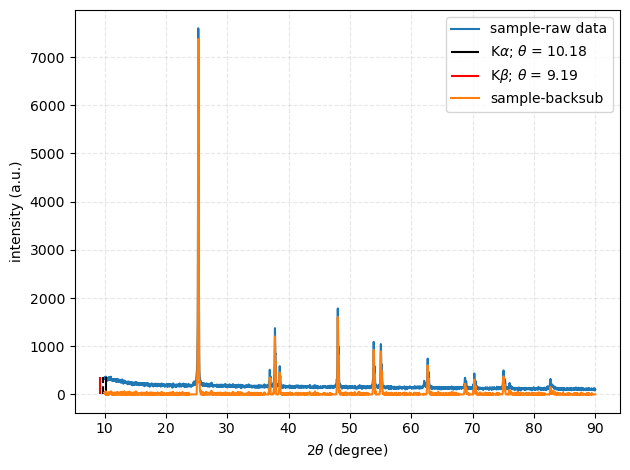

In [2]:
# Set environments
import powerxrd as xrd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Run the code
def test_backsub():
    # open file from our folder - recommend use pandas
    open_file = "../diff_data/sample.xy"

    try: # use pandas to read the file
        df = pd.read_csv(open_file, sep=r'\s+', header=None, comment='#')
        x = df[0].values
        y = df[1].values
        data = (x, y)
    except Exception as e:
        print(f"error reading the file:{e}")
        print("check sample.xy")
        return None

    # Load data into algorithm
    plt.plot(*data, label='sample-raw data')

    chart = xrd.Chart(*data)
    chart.emission_lines(xrange_Ka=[10, 20], show = True)

    # Calculate background substraction
    backsub_data = chart.backsub() # powerxrd returns a tuple of (x, y corrected)
    plt.plot(*backsub_data, label='sample-backsub')
    plt.xlabel(r'2$\theta$ (degree)')
    plt.ylabel('intensity (a.u.)')
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.legend()
    plt.savefig("single plot vs backsub plot.svg", bbox_inches='tight')
    plt.show

# Return the data to save as the function
    return backsub_data

# Run final function
sample_backsub = test_backsub()

In [29]:
# save the data 
if sample_backsub is not None:
    export_data = np.column_stack((sample_backsub[0], sample_backsub[1]))

    np.savetxt("sample_backsub.csv", export_data, delimiter=",", header= "2q, intensity", comments="")
    


-------------------------------------------
ALLPEAKS: Automated Scherrer width calculations with a recursive search of local maxima

local_max -- max x: 25.19481 max y: 4342.6


local_max -- max x: 25.19481 max y: 4342.6

-Gaussian fit results-
y-shift 13.967378903363045
amplitude 1019.8175774557429
mean 25.199525320574708
sigma 0.09092184208508035
covariance matrix 
[[ 3.33666175e+01 -1.61316198e+01 -3.64246151e-09 -9.58811667e-04]
 [-1.61316198e+01  3.19572512e+01  1.17554141e-09  1.89943807e-03]
 [-3.64246151e-09  1.17554141e-09  2.56032298e-07  3.29241435e-12]
 [-9.58811667e-04  1.89943807e-03  3.29241435e-12  2.83584319e-07]]

SchPeak: Scherrer width calc. for peak in range of [24.19481,26.19481]

FWHM == sigma*2*sqrt(2*ln(2)): 0.21410457627308577 degrees
K (shape factor): 0.9
K-alpha: 0.15406 nm 
max 2-theta: 25.19481 degrees

SCHERRER WIDTH: 38.01998242688474 nm
local_max -- max x: 24.92931 max y: 129.10000000000002
local_max -- max x: 47.96646 max y: 1012.3000000000002

-Gauss

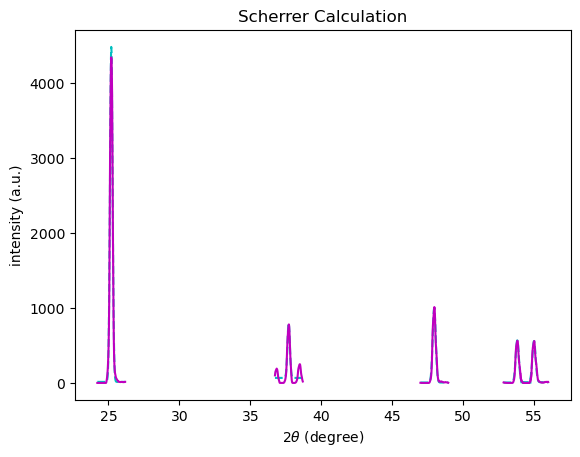

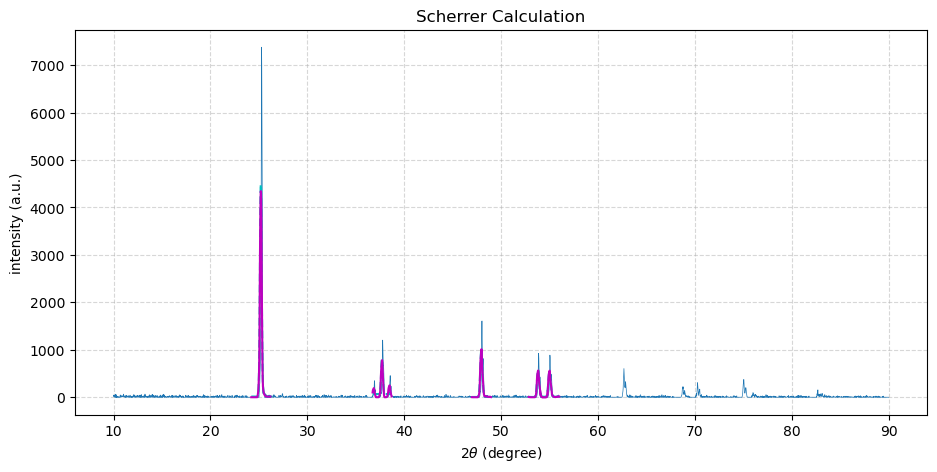

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import powerxrd as xrd


def test_allpeaks():
    file_path = "../diff_data/sample_backsub.csv"

    try:
        df = pd.read_csv(file_path, sep=r",", header=None, comment="#")
        df[0] = pd.to_numeric(df[0], errors='coerce')
        df[1] = pd.to_numeric(df[1], errors='coerce')
        df = df.dropna()
        x = df[0].values
        y = df[1].values
        data = (x, y)

    except Exception as e:
        print(f'error reading file:{e}')
        return
        
    chart = xrd.Chart(*data)

    # 1. Subtract background
    chart.backsub(tol=1, show=False)

    # 2. Smooth data with a 10-point moving average to eliminate recursion-triggering noise
    # This overwrites chart.x and chart.y with cleaner data
    chart.x, chart.y = chart.mav(n=10)
    
    # 3. Run peak finder on the smoothed data
    chart.allpeaks(tols=(0.11, 1.0), verbose=True, show=True)
    plt.xlabel(r"2$\theta$ (degree)")
    plt.ylabel('intensity (a.u.)')
    plt.title("Scherrer Calculation")
    
    plt.figure(figsize=(11, 5))
    plt.plot(*data, label='sample-raw data', lw=0.5)
    chart.allpeaks(tols=(0.11, 1.0), verbose=True, show=True)
    
    plt.xlabel(r"2$\theta$ (degree)")
    plt.ylabel('intensity (a.u.)')
    plt.title("Scherrer Calculation")
    plt.grid(alpha=0.5, linestyle='--')
    plt.show()


    
test_allpeaks()